In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('data/train_and_test2.csv')
df.head(3)

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [4]:
cols_to_drop = df.columns.str.contains('zero', regex=False)
df = df.drop(columns=df.columns[cols_to_drop])
df = df.drop(columns=['Passengerid'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1309 non-null   float64
 1   Fare      1309 non-null   float64
 2   Sex       1309 non-null   int64  
 3   sibsp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Pclass    1309 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   2urvived  1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [5]:
df = df.rename(columns={'2urvived' : 'Survived'})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1309 non-null   float64
 1   Fare      1309 non-null   float64
 2   Sex       1309 non-null   int64  
 3   sibsp     1309 non-null   int64  
 4   Parch     1309 non-null   int64  
 5   Pclass    1309 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1309 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 81.9 KB


In [6]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1307 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1307 non-null   float64
 1   Fare      1307 non-null   float64
 2   Sex       1307 non-null   int64  
 3   sibsp     1307 non-null   int64  
 4   Parch     1307 non-null   int64  
 5   Pclass    1307 non-null   int64  
 6   Embarked  1307 non-null   float64
 7   Survived  1307 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 91.9 KB


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('Survived', axis=1)
y = df['Survived']

print(f'X.shape: {X.shape}')
print(f'y.shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 딥러닝은 처리하기 전에 스케일링이 필요하다

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

print(f'X_train_scaled.shape: {X_train_scaled.shape}')
print(f'X_test_scaled.shape: {X_test_scaled.shape}')
print(f'y_train.shape: {y_train.shape}')
print(f'y_test.shape: {y_test.shape}')

X.shape: (1307, 7)
y.shape: (1307,)
X_train_scaled.shape: (1045, 7)
X_test_scaled.shape: (262, 7)
y_train.shape: (1045,)
y_test.shape: (262,)


In [8]:
# 딥러닝 모델 생성하기
import tensorflow as tf
from tensorflow.keras import Sequential, layers

tf.random.set_seed(42)

model = Sequential([
    # Dense를 이용해 (첫번째)은닉층을 만드는데, 이때 input_shape가 입력층도 생성함
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),    # activation='relu': 활성함수를 relu로 지정 (음수값들을 제거)
    layers.Dense(16, activation='relu'),    # 두번째 은닉층 추가
    layers.Dense(1, activation='sigmoid')     # binary로 만듦(0에 가깝게 만들거나 1에 가깝게 만들어줌)
])  # 각각의 층(입력층, 은닉층, 출력층)들을 layer객체로 추가해준다.

model.compile(
    optimizer='adam',    # 경사하강법을 최적으로 구하는 함수
    loss='binary_crossentropy', # 둘 중에 하나를 분류(Binary Classification)
    metrics=['accuracy']    # 모니터링용
)

model.summary()

C:\Users\heyum\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras import callbacks, optimizers
# 감시를 하면서 과적합 방지를 위하여 조기 종료 조건을 설정해준다.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',     # 감시할 대상을 설정(검증데이터의 손실값)
    patience=20,            # 최근 20회동안의 개선이 없으면 동작
    restore_best_weights=True   # 가장 결과가 좋았을때의 가중치로 돌려놓음
)



# 딥러닝 학습
history = model.fit(
    X_train_scaled, y_train,    # 입력 데이터(학습, 검증)
    validation_split=0.2,   # 검증용으로 다시 8:2로 나눔
    epochs=100,     # 학습 시도 횟수
    batch_size=32,  # 한번에 입력될 데이터의 개수
    callbacks=[early_stop],
    verbose=1       # 학습 과정을 보일지 여부
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3840 - loss: 0.7455 - val_accuracy: 0.6507 - val_loss: 0.6770
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6687 - loss: 0.6427 - val_accuracy: 0.7368 - val_loss: 0.5873
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7368 - loss: 0.5720 - val_accuracy: 0.7560 - val_loss: 0.5284
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7452 - loss: 0.5283 - val_accuracy: 0.7560 - val_loss: 0.4935
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7512 - loss: 0.5007 - val_accuracy: 0.7751 - val_loss: 0.4721
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7536 - loss: 0.4820 - val_accuracy: 0.7847 - val_loss: 0.4608
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7560 - loss: 0.4690 - val_accuracy: 0.7799 - val_loss: 0.4542
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7691 - loss: 0.4598 - val_accuracy: 0.7990 - v

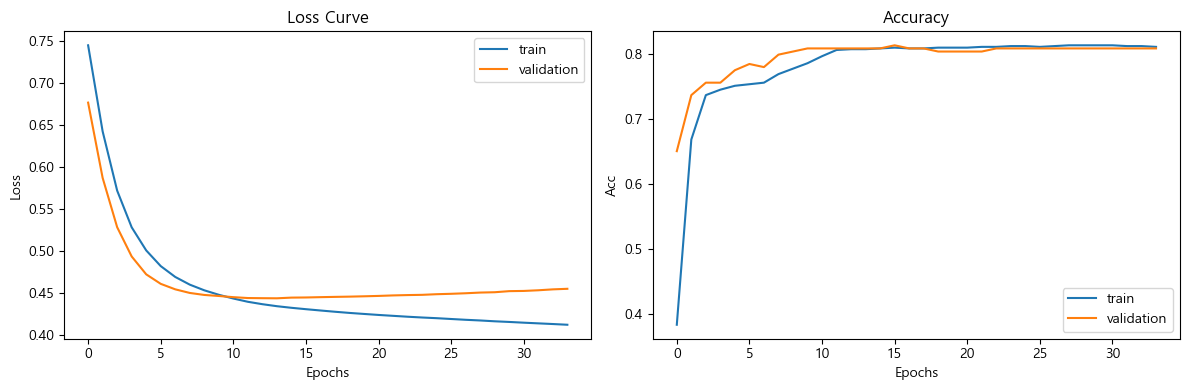

In [10]:
# 학습과정을 그래프로 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')    # 학습데이터의 손실값의 변화량
plt.plot(history.history['val_loss'], label='validation') # 검증 데이터의 손실값의 변화량
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')    # 학습데이터의 손실값의 변화량
plt.plot(history.history['val_accuracy'], label='validation') # 검증 데이터의 손실값의 변화량
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
# 모델 개선하기

tf.random.set_seed(42)
improved_model = Sequential([
    layers.Dense(64, input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),    # 파라미터의 값들을 스케일링하여 정확도를 높인다
    layers.Activation('relu'),
    layers.Dropout(0.3),     # 무작위로 30%의 뉴런의 신호를 강제로 끈다 --> 과적합 방지


    layers.Dense(32),
    layers.BatchNormalization(),    # 파라미터의 값들을 스케일링하여 정확도를 높인다
    layers.Activation('relu'),
    layers.Dropout(0.2),     # 무작위로 20%의 뉴런의 신호를 강제로 끈다 --> 과적합 방지

    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])

# compile
improved_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

C:\Users\heyum\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 192 (768.00 B)

In [15]:


early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history_imp = improved_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7428 - loss: 0.5686 - val_accuracy: 0.8134 - val_loss: 0.5612
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7572 - loss: 0.5120 - val_accuracy: 0.8182 - val_loss: 0.5185
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7632 - loss: 0.5103 - val_accuracy: 0.8278 - val_loss: 0.4845
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7751 - loss: 0.4825 - val_accuracy: 0.8230 - val_loss: 0.4661
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7679 - loss: 0.4723 - val_accuracy: 0.8230 - val_loss: 0.4561
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7739 - loss: 0.4711 - val_accuracy: 0.8134 - val_loss: 0.4533
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7799 - loss: 0.4745 - val_accuracy: 0.8182 - val_loss: 0.4514
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7823 - loss: 0.4742 - val_accuracy: 0.8038 - v

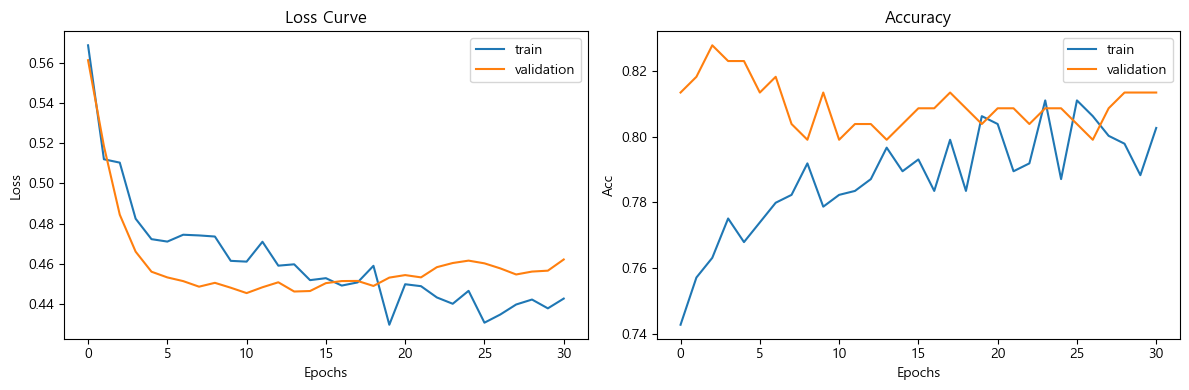

In [16]:
# 학습과정을 그래프로 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_imp.history['loss'], label='train')    # 학습데이터의 손실값의 변화량
plt.plot(history_imp.history['val_loss'], label='validation') # 검증 데이터의 손실값의 변화량
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_imp.history['accuracy'], label='train')    # 학습데이터의 손실값의 변화량
plt.plot(history_imp.history['val_accuracy'], label='validation') # 검증 데이터의 손실값의 변화량
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.legend()

plt.tight_layout()
plt.show()